# Aufgabe 2 - Tiefe Einblicke ins Institut

Den Code immer nachvollziehbar kommentieren! Bitte beachtet, dass das Notebook von Anfang bis Ende ohne Fehler durchlaufen muss und dass die requirements.txt Datei aktualisiert wird. 

## Teilaufgabe a): Trainings-und Testdatenset

In [1]:
rooms = ['Flur', 'Labor', 'Professorenbuero', 'Teekueche']
training_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(1,20)]  # ["./pfad/zu/bildA.png","./pfad/zu/bildB.png",...]
test_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(20,26)]  # ["./pfad/zu/bildC.png","./pfad/zu/bildD.png",...]

## Teilaufgabe b): Verteilung RGB

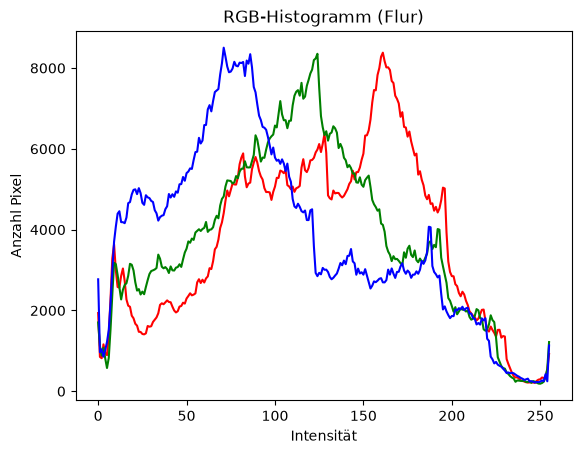

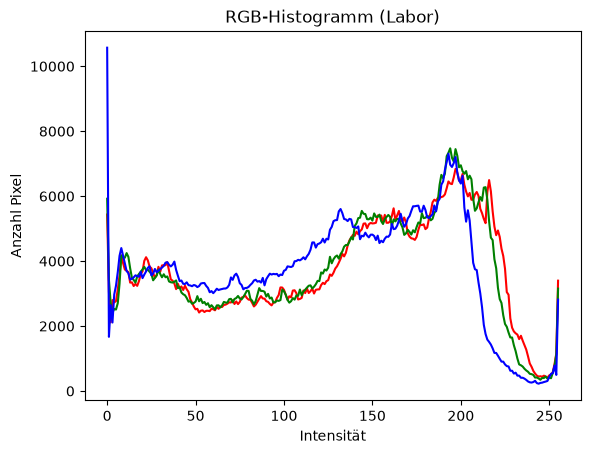

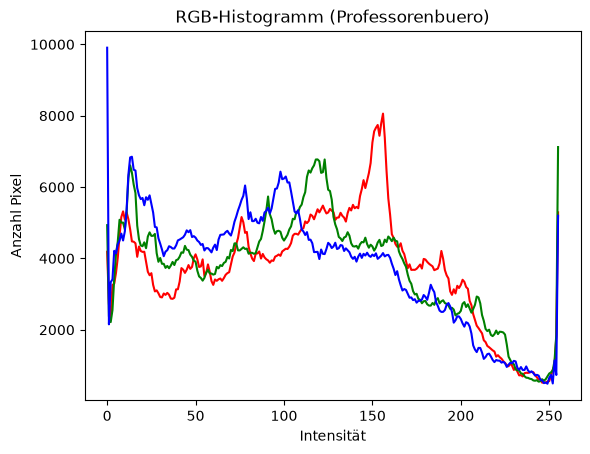

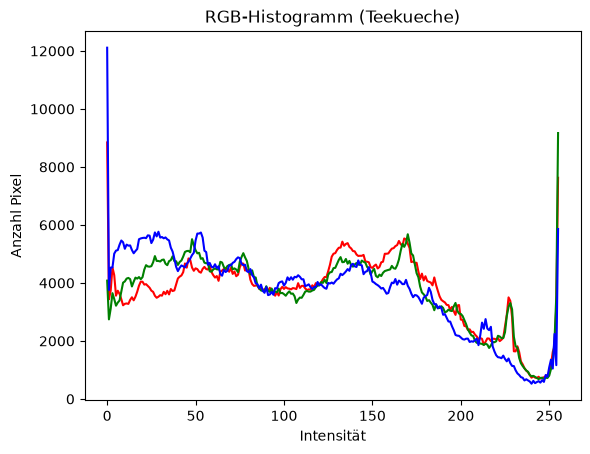

In [2]:
import numpy as np
import matplotlib.pyplot as plt

for room in rooms:
    r_ges = []
    g_ges = []
    b_ges = []
    for path in training_path_list:
        if path.split('/')[1] != room: continue
        img = plt.imread(path)
        r = img[:, :, 0]
        g = img[:, :, 1]
        b = img[:, :, 2]
        for k in range(len(r)):
            r_ges.append(r[k])
        for k in range(len(g)):
            g_ges.append(g[k])
        for k in range(len(b)):
            b_ges.append(b[k])
        
    hist_r, bins = np.histogram(r_ges, bins=256, range=(0, 256))
    hist_g, _    = np.histogram(g_ges, bins=256, range=(0, 256))
    hist_b, _    = np.histogram(b_ges, bins=256, range=(0, 256))

    # hist_r = [k/20 for k in hist_r]
    # hist_g = [k/20 for k in hist_g]
    # hist_b = [k/20 for k in hist_b]

    plt.plot(hist_r, color="red")
    plt.plot(hist_g, color="green")
    plt.plot(hist_b, color="blue")
    plt.xlabel("Intensität")
    plt.ylabel("Anzahl Pixel")
    plt.title(f"RGB-Histogramm ({room})")
    plt.show()

## Teilaufgabe c): Training und Test mit Random Forest 

In [4]:
from PIL import Image
from pathlib import Path

def extract_features(path):
    img = np.array(Image.open(path).convert("RGB"))
    bins = 64
    hist_r, _ = np.histogram(img[:,:,0], bins=bins, range=(0,256))
    hist_g, _ = np.histogram(img[:,:,1], bins=bins, range=(0,256))
    hist_b, _ = np.histogram(img[:,:,2], bins=bins, range=(0,256))

    return np.concatenate([hist_r, hist_g, hist_b])


X_train = np.array([extract_features(p) for p in training_path_list])
X_test  = np.array([extract_features(p) for p in test_path_list])

from pathlib import Path

y_train = [Path(p).parent.name for p in training_path_list]
y_test = [Path(p).parent.name for p in test_path_list]

y_train = [Path(p).parent.name for p in training_path_list]

In [7]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=2000,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [6]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.2 MB 13.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 13.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.4 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.6 MB 13.4 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/36.6 MB 13.1 MB/s eta 0:00:03
   -------- ------------------------------- 7.6/36.6 MB 13.1 MB/s eta 0:00:03
   ----------- ---------------------------- 10.2/36.6 MB 13.0 MB/s eta 0:00:03
   ------------- -------------------------- 12.6/36.6 MB 12.9 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/36.6 MB 12.9 MB/s eta 0:00:02
   ------------------- -------------------- 17.8/36.6 MB 12.8 MB/s eta 0:00:02
   ---

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.75
Precision: 0.7848214285714286
Recall   : 0.75
F1       : 0.7526973026973027


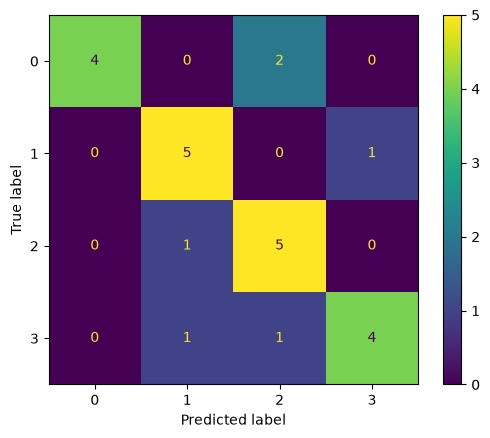

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe d): Hyperparameteroptimierung

In [11]:
!pip install seaborn

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.8 MB 12.6 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.8 MB 13.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 12.4 MB/s  0:00:00

   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# X_train, y_train, X_test, y_test stammen aus Aufgabe c

param_grid = {
    'n_estimators': [100, 1000, 2000]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Beste Parameter:")
print(grid.best_params_)

Beste Parameter:
{'n_estimators': 1000}


In [36]:
best_rf = grid.best_estimator_


best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.75
Precision: 0.7848214285714286
Recall   : 0.75
F1       : 0.7526973026973027


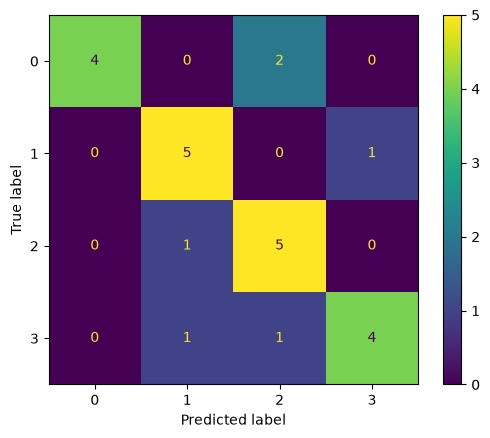

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe e): Dimensionalitätsreduktion

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Alte Dimension:", X_train.shape[1])
print("Neue Dimension:", X_train_pca.shape[1])

Alte Dimension: 192
Neue Dimension: 31


In [47]:
param_grid = {
    'n_estimators': [100, 1000, 2000]
}

rf = RandomForestClassifier(random_state=42)

grid_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_pca.fit(X_train_pca, y_train)

print("Beste Parameter mit PCA:")
print(grid_pca.best_params_)

Beste Parameter mit PCA:
{'n_estimators': 2000}


In [48]:
best_rf_pca = RandomForestClassifier(
    n_estimators=grid_pca.best_params_['n_estimators'],
    random_state=42
)

best_rf_pca.fit(X_train_pca, y_train)

y_pred_pca = best_rf_pca.predict(X_test_pca)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_pca))
print("Precision:", precision_score(y_test, y_pred_pca, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_pca, average="weighted"))
print("F1       :", f1_score(y_test, y_pred_pca, average="weighted"))

Accuracy : 0.5833333333333334
Precision: 0.6428571428571429
Recall   : 0.5833333333333334
F1       : 0.5883699633699634


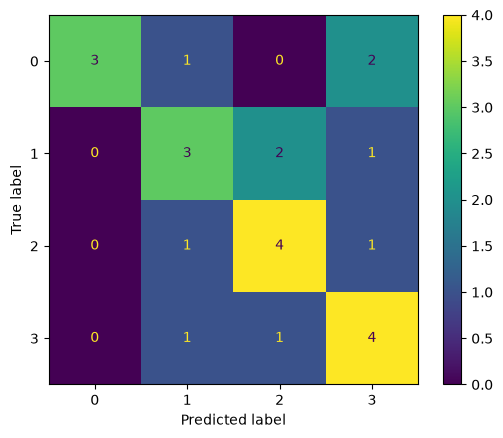

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_pca)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()